<a href="https://colab.research.google.com/github/SARU230/Matplot_lib_for-gromacs/blob/main/gmx_distance__editable.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving 44a_45_t_dist.xvg to 44a_45_t_dist (15).xvg
Enter the title for the plots: 5
Select the plots to generate:
1. Plot raw distance over time
2. Plot change in distance over time
3. Plot first derivative of distance over time
4. Plot histogram of raw distances
5. Plot histogram of distance changes
Enter your choices (comma-separated, e.g., 1,2,3): 5


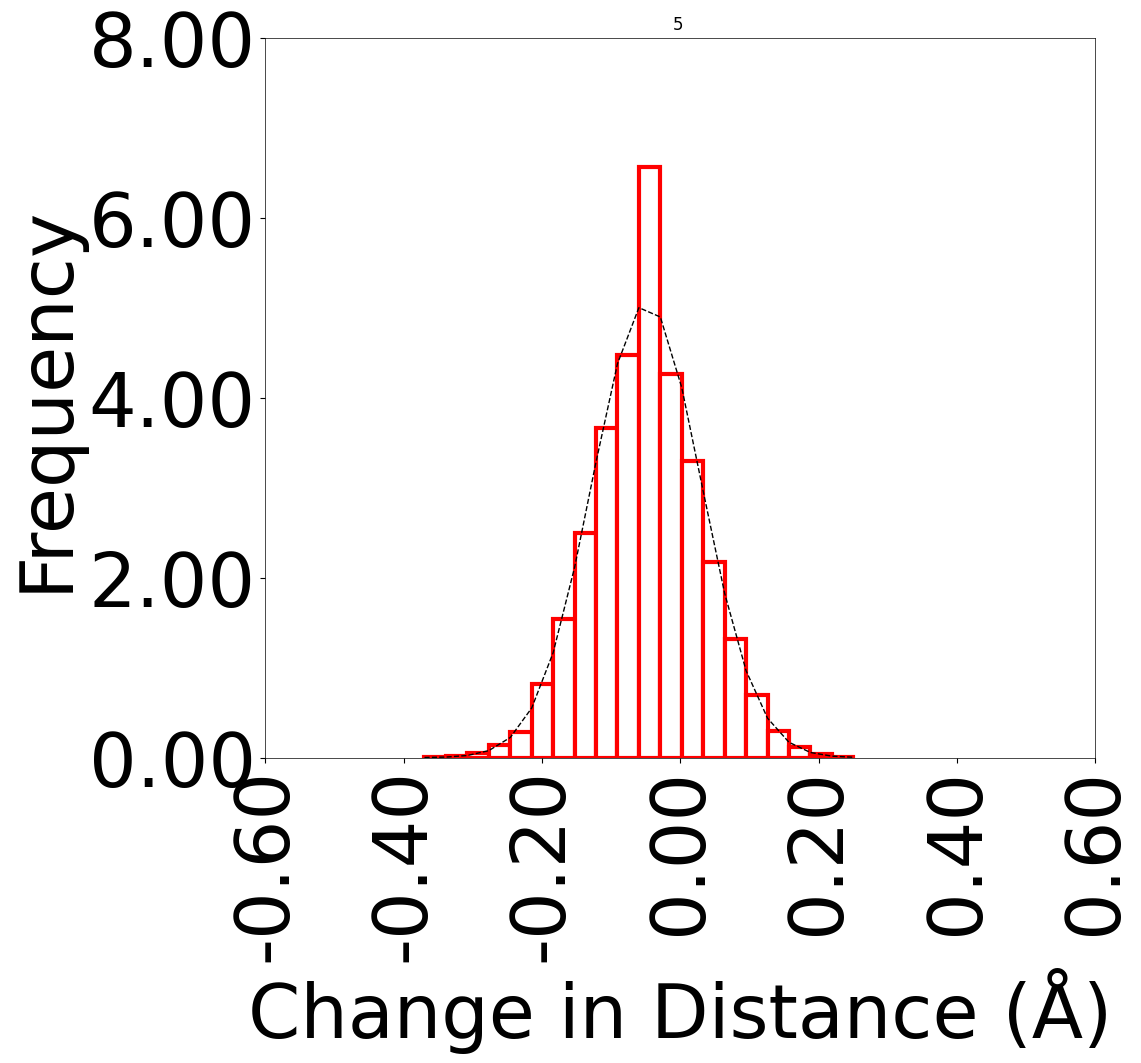

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import norm
from google.colab import files
import warnings
import logging

# SUPPRESS warnings + set clean sans-serif + NO FIGURE NUMBER
plt.ioff()  # Turn off interactive mode - KILLS figure numbering
logging.getLogger('matplotlib.font_manager').setLevel(logging.CRITICAL)
plt.rcParams['font.family'] = ['sans-serif']

# Font size settings - modify these to change font sizes globally
AXIS_LABEL_FONTSIZE = 54  # Font size for axis labels (xlabel, ylabel)
TICK_LABEL_FONTSIZE = 54  # Font size for tick marks/numbers
TITLE_FONTSIZE = 12       # Font size for plot titles
LEGEND_FONTSIZE = 12      # Font size for legends
X_TICK_ROTATION = 90      # Rotation angle for x-axis tick labels (0 = horizontal, 45 = tilted, 90 = vertical)

def read_xvg(file_path):
    """
    Read an .xvg file and extract time and overall distance.
    Convert distance from nm to Å.
    """
    time = []
    distance = []

    with open(file_path, 'r') as file:
        for line in file:
            # Skip comments and headers
            if line.startswith('#') or line.startswith('@'):
                continue
            # Split the line into columns
            columns = line.split()
            if len(columns) == 2:  # Ensure there are 2 columns (time, distance)
                time.append(float(columns[0]))
                distance.append(float(columns[1]) * 10)  # Convert nm to Å

    return np.array(time), np.array(distance)

def calculate_changes(distance):
    """
    Calculate the change in distance relative to t = 0.
    """
    return distance - distance[0]

def calculate_derivatives(time, distance):
    """
    Calculate the first derivative of distance with respect to time.
    """
    dt = time[1] - time[0]  # Time step
    return np.gradient(distance, dt) * 10  # Convert nm/ps to Å/ps

def plot_distance(time, distance, title):
    """
    Plot distance over time.
    Distance is in Å.
    """
    fig = plt.figure(figsize=(15, 8), num=None)  # num=None kills figure number
    plt.plot(time, distance, label='Distance (Å)', color='r', linestyle='-')
    plt.xlabel('Time (ps)', fontsize=AXIS_LABEL_FONTSIZE)
    plt.ylabel('Distance (Å)', fontsize=AXIS_LABEL_FONTSIZE)
    plt.title(f'{title} - Distance Over Time', fontsize=TITLE_FONTSIZE)
    plt.legend(fontsize=LEGEND_FONTSIZE)
    plt.grid(True)

    # Set axis limits
    plt.xlim(0, 20000)
    plt.ylim(np.min(distance)-1, np.max(distance)+1)

    # Customize major tick spacing and format
    major_spacing_x = 2500
    major_spacing_y = 0.5
    ax = plt.gca()
    ax.xaxis.set_major_locator(ticker.MultipleLocator(major_spacing_x))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(major_spacing_y))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))  # Set decimal places

    # Set tick label font sizes and rotation
    plt.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONTSIZE)
    plt.xticks(rotation=X_TICK_ROTATION)

    # Increase box frame width
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(2)

    plt.show()
    plt.close(fig)  # Clean up after each plot

def plot_distance_changes(time, change, title):
    """
    Plot changes in distance over time.
    Changes are in Å.
    """
    fig = plt.figure(figsize=(14, 8), num=None)  # num=None kills figure number
    plt.plot(time, change, label='Change in Distance (Å)', color='b', linestyle='-')
    plt.xlabel('Time (ps)', fontsize=AXIS_LABEL_FONTSIZE)
    plt.ylabel('Change in Distance (Å)', fontsize=AXIS_LABEL_FONTSIZE)
    plt.title(f'{title} - Change in Distance Over Time', fontsize=TITLE_FONTSIZE)
    plt.legend(fontsize=LEGEND_FONTSIZE)
    plt.grid(True)

    # Set axis limits
    plt.xlim(0, 20000)
    plt.ylim(np.min(change)-0.1, np.max(change)+0.1)

    # Customize major tick spacing and format
    major_spacing_x = 2500
    major_spacing_y = 0.05
    ax = plt.gca()
    ax.xaxis.set_major_locator(ticker.MultipleLocator(major_spacing_x))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(major_spacing_y))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))  # Set decimal places

    # Set tick label font sizes and rotation
    plt.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONTSIZE)
    plt.xticks(rotation=X_TICK_ROTATION)

    # Increase box frame width
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(2)

    plt.show()
    plt.close(fig)

def plot_distance_derivative(time, derivative, title):
    """
    Plot the first derivative of distance over time.
    Derivatives are in Å/ps.
    """
    fig = plt.figure(figsize=(14, 8), num=None)  # num=None kills figure number
    plt.plot(time, derivative, label='dDistance/dt (Å/ps)', color='g', linestyle='-')
    plt.xlabel('Time (ps)', fontsize=AXIS_LABEL_FONTSIZE)
    plt.ylabel('Rate of Change (Å/ps)', fontsize=AXIS_LABEL_FONTSIZE)
    plt.title(f'{title} - First Derivative of Distance Over Time', fontsize=TITLE_FONTSIZE)
    #plt.legend(fontsize=LEGEND_FONTSIZE)
    plt.grid(True)

    # Set axis limits
    plt.xlim(0, 20000)
    plt.ylim(np.min(derivative)-0.01, np.max(derivative)+0.01)

    # Customize major tick spacing and format
    major_spacing_x = 2500
    major_spacing_y = 0.01
    ax = plt.gca()
    ax.xaxis.set_major_locator(ticker.MultipleLocator(major_spacing_x))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(major_spacing_y))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))  # Set decimal places

    # Set tick label font sizes and rotation
    plt.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONTSIZE)
    plt.xticks(rotation=X_TICK_ROTATION)

    # Increase box frame width
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(1)

    plt.show()
    plt.close(fig)

def plot_histogram(data, title, xlabel, xlim=None, ylim=None):
    """
    Plot histogram of distance data with Gaussian fit.
    """
    fig = plt.figure(figsize=(10, 10), num=None)  # num=None kills figure number
    n, bins, patches = plt.hist(data, bins=20, color='white', alpha=1, edgecolor='red', linewidth=3, density=True)
    plt.xlabel(xlabel, fontsize=AXIS_LABEL_FONTSIZE)
    plt.ylabel('Frequency', fontsize=AXIS_LABEL_FONTSIZE)
    plt.title(title, fontsize=TITLE_FONTSIZE)
#colours red green saddlebrown cyan
#colours lime burlywood  darkviolet turquoise
    # Fit a Gaussian curve
    mu, sigma = norm.fit(data)
    variance = np.var(data)
    best_fit_line = norm.pdf(bins, mu, sigma)
    plt.plot(bins, best_fit_line, 'k--', linewidth=1, label=f'μ = {mu:.3f}\nσ² = {variance:.3f}')
    #plt.legend(fontsize=LEGEND_FONTSIZE)

    if xlim:
        plt.xlim(xlim)
    if ylim:
        plt.ylim(ylim)

    # Increase box frame width and set decimal places
    ax = plt.gca()
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(0.5)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

    # Set tick label font sizes and rotation
    plt.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONTSIZE)
    plt.xticks(rotation=X_TICK_ROTATION)

    major_spacing_x = 0.2  # Set major tick spacing for x-axis
    major_spacing_y = 2.0  # Set major tick spacing for y-axis
    ax.xaxis.set_major_locator(ticker.MultipleLocator(major_spacing_x))  # Set x-axis spacing
    ax.yaxis.set_major_locator(ticker.MultipleLocator(major_spacing_y))  # Set y-axis spacing
    plt.show()
    plt.close(fig)

def main():
    # Upload the .xvg file
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]

    # Ask for the title name
    title = input("Enter the title for the plots: ")

    # Read the .xvg file
    time, distance = read_xvg(file_name)

    # Calculate changes and derivatives
    change = calculate_changes(distance)
    derivative = calculate_derivatives(time, distance)

    # Ask the user which plots to generate
    print("Select the plots to generate:")
    print("1. Plot raw distance over time")
    print("2. Plot change in distance over time")
    print("3. Plot first derivative of distance over time")
    print("4. Plot histogram of raw distances")
    print("5. Plot histogram of distance changes")
    choices = input("Enter your choices (comma-separated, e.g., 1,2,3): ").strip().split(',')

    # Generate the selected plots
    if '1' in choices:
        plot_distance(time, distance, title)
    if '2' in choices:
        plot_distance_changes(time, change, title)
    if '3' in choices:
        plot_distance_derivative(time, derivative, title)
    if '4' in choices:
        plot_histogram(
            distance,
            f'{title} - Histogram of Distances',
            'Distance (Å)',
            xlim=(np.min(distance)-1, np.max(distance)+1),
            ylim=(0, 100)
        )
    if '5' in choices:
        plot_histogram(
            change,
            f'{title} ',
            'Change in Distance (Å)',
            xlim=(-0.6, 0.6),
            ylim=(0, 8)
        )

if __name__ == "__main__":
    main()


Saving 44a_45_t_dist.xvg to 44a_45_t_dist (19).xvg
Enter the title for the plots: 5
Select the plots to generate:
1. Plot raw distance over time
2. Plot change in distance over time
3. Plot first derivative of distance over time
4. Plot histogram of raw distances
5. Plot histogram of distance changes
Enter your choices (comma-separated, e.g., 1,2,3): 5


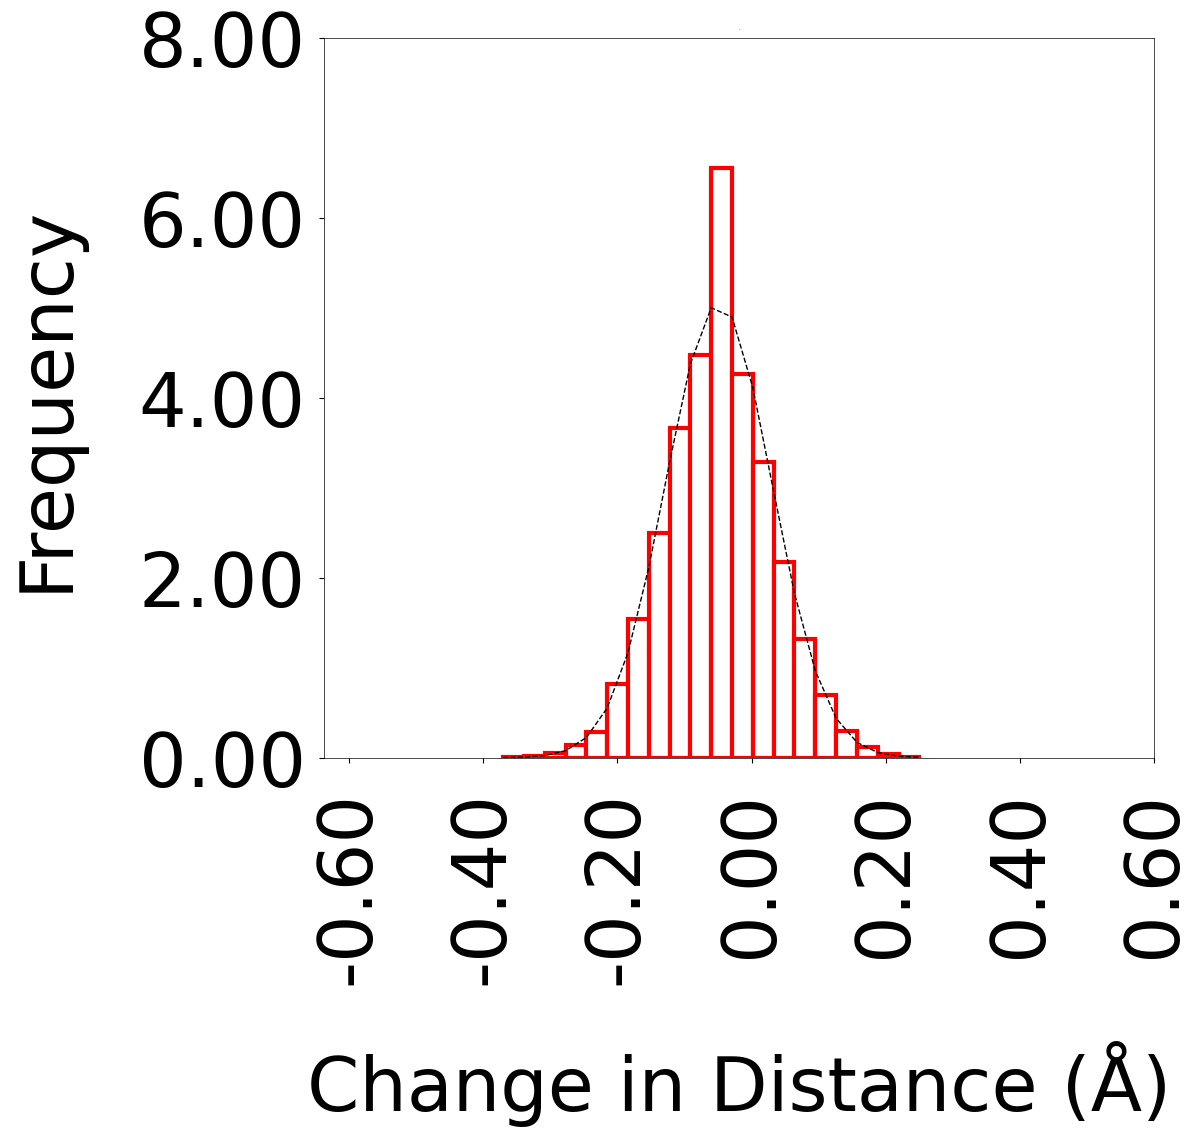

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import norm
from google.colab import files
import warnings
import logging

# GLOBAL CONFIG - ONE PLACE TO CONTROL ALL 5 PLOTS
plt.ioff()  # No figure numbers
logging.getLogger('matplotlib.font_manager').setLevel(logging.CRITICAL)
plt.rcParams['font.family'] = ['sans-serif']

# 🎚️ YOUR CONTROLS - CHANGE THESE NUMBERS:
plt.rcParams['figure.subplot.left'] = 0.12     # Left margin (0.10=less, 0.15=more)
plt.rcParams['figure.subplot.right'] = 0.95    # Right margin
plt.rcParams['figure.subplot.bottom'] = 0.18   # Bottom margin (0.15=less, 0.22=more)
plt.rcParams['figure.subplot.top'] = 0.90      # Top margin

# Font sizes
AXIS_LABEL_FONTSIZE = 54
TICK_LABEL_FONTSIZE = 54
TITLE_FONTSIZE = 0
LEGEND_FONTSIZE = 12
X_TICK_ROTATION = 90

# ── Overlap fix ──────────────────────────────────────────────────────────────
X_PAD = 20   # horizontal distance between x-tick labels and x-axis spine
Y_PAD = 10   # vertical distance between y-tick labels and y-axis spine
XLIM_LEFT_MARGIN = 0.03
# ─────────────────────────────────────────────────────────────────────────────

# ── Axis title spacing ───────────────────────────────────────────────────────
# Distance (in points) between the tick labels and the axis title.
# Increase either value if the title still crowds the tick labels.
X_LABELPAD = 40   # gap between x-tick labels and x-axis title
Y_LABELPAD = 40   # gap between y-tick labels and y-axis title
# ─────────────────────────────────────────────────────────────────────────────


def _apply_overlap_fix(ax, x_min, x_max):
    """Push the first x-tick away from the y-axis on any axes object."""
    ax.tick_params(axis='x', pad=X_PAD)
    ax.tick_params(axis='y', pad=Y_PAD)
    margin = (x_max - x_min) * XLIM_LEFT_MARGIN
    ax.set_xlim(x_min - margin, ax.get_xlim()[1])


def read_xvg(file_path):
    time = []
    distance = []
    with open(file_path, 'r') as file:
        for line in file:
            if line.startswith('#') or line.startswith('@'):
                continue
            columns = line.split()
            if len(columns) == 2:
                time.append(float(columns[0]))
                distance.append(float(columns[1]) * 10)
    return np.array(time), np.array(distance)


def calculate_changes(distance):
    return distance - distance[0]


def calculate_derivatives(time, distance):
    dt = time[1] - time[0]
    return np.gradient(distance, dt) * 10


def plot_distance(time, distance, title):
    fig = plt.figure(figsize=(15, 8), num=None)
    plt.plot(time, distance, label='Distance (Å)', color='r', linestyle='-')
    plt.xlabel('Time (ps)', fontsize=AXIS_LABEL_FONTSIZE, labelpad=X_LABELPAD)
    plt.ylabel('Distance (Å)', fontsize=AXIS_LABEL_FONTSIZE, labelpad=Y_LABELPAD)
    plt.title(f'{title} - Distance Over Time', fontsize=TITLE_FONTSIZE)
    plt.legend(fontsize=LEGEND_FONTSIZE)
    plt.grid(True)
    plt.xlim(0, 20000)
    plt.ylim(np.min(distance) - 1, np.max(distance) + 1)

    major_spacing_x = 2500
    major_spacing_y = 0.5
    ax = plt.gca()
    ax.xaxis.set_major_locator(ticker.MultipleLocator(major_spacing_x))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(major_spacing_y))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
    plt.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONTSIZE)
    plt.xticks(rotation=X_TICK_ROTATION)
    for axis in ['top', 'bottom', 'left', 'right']:
        ax.spines[axis].set_linewidth(2)

    _apply_overlap_fix(ax, 0, 20000)   # ← overlap fix

    plt.show()
    plt.close(fig)


def plot_distance_changes(time, change, title):
    fig = plt.figure(figsize=(14, 8), num=None)
    plt.plot(time, change, label='Change in Distance (Å)', color='b', linestyle='-')
    plt.xlabel('Time (ps)', fontsize=AXIS_LABEL_FONTSIZE, labelpad=X_LABELPAD)
    plt.ylabel('Change in Distance (Å)', fontsize=AXIS_LABEL_FONTSIZE, labelpad=Y_LABELPAD)
    plt.title(f'{title} - Change in Distance Over Time', fontsize=TITLE_FONTSIZE)
    plt.legend(fontsize=LEGEND_FONTSIZE)
    plt.grid(True)
    plt.xlim(0, 20000)
    plt.ylim(np.min(change) - 0.1, np.max(change) + 0.1)

    major_spacing_x = 2500
    major_spacing_y = 0.05
    ax = plt.gca()
    ax.xaxis.set_major_locator(ticker.MultipleLocator(major_spacing_x))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(major_spacing_y))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
    plt.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONTSIZE)
    plt.xticks(rotation=X_TICK_ROTATION)
    for axis in ['top', 'bottom', 'left', 'right']:
        ax.spines[axis].set_linewidth(2)

    _apply_overlap_fix(ax, 0, 20000)   # ← overlap fix

    plt.show()
    plt.close(fig)


def plot_distance_derivative(time, derivative, title):
    fig = plt.figure(figsize=(14, 8), num=None)
    plt.plot(time, derivative, label='dDistance/dt (Å/ps)', color='g', linestyle='-')
    plt.xlabel('Time (ps)', fontsize=AXIS_LABEL_FONTSIZE, labelpad=X_LABELPAD)
    plt.ylabel('Rate of Change (Å/ps)', fontsize=AXIS_LABEL_FONTSIZE, labelpad=Y_LABELPAD)
    plt.title(f'{title} - First Derivative of Distance Over Time', fontsize=TITLE_FONTSIZE)
    plt.grid(True)
    plt.xlim(0, 20000)
    plt.ylim(np.min(derivative) - 0.01, np.max(derivative) + 0.01)

    major_spacing_x = 2500
    major_spacing_y = 0.01
    ax = plt.gca()
    ax.xaxis.set_major_locator(ticker.MultipleLocator(major_spacing_x))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(major_spacing_y))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
    plt.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONTSIZE)
    plt.xticks(rotation=X_TICK_ROTATION)
    for axis in ['top', 'bottom', 'left', 'right']:
        ax.spines[axis].set_linewidth(1)

    _apply_overlap_fix(ax, 0, 20000)   # ← overlap fix

    plt.show()
    plt.close(fig)


def plot_histogram(data, title, xlabel, xlim=None, ylim=None):
    fig = plt.figure(figsize=(10, 10), num=None)
    n, bins, patches = plt.hist(data, bins=20, color='white', alpha=1,
                                edgecolor='red', linewidth=3, density=True)
    plt.xlabel(xlabel, fontsize=AXIS_LABEL_FONTSIZE, labelpad=X_LABELPAD)
    plt.ylabel('Frequency', fontsize=AXIS_LABEL_FONTSIZE, labelpad=Y_LABELPAD)
    plt.title(title, fontsize=TITLE_FONTSIZE)

    mu, sigma = norm.fit(data)
    variance = np.var(data)
    best_fit_line = norm.pdf(bins, mu, sigma)
    plt.plot(bins, best_fit_line, 'k--', linewidth=1,
             label=f'μ = {mu:.3f}\nσ² = {variance:.3f}')

    if xlim:
        plt.xlim(xlim)
    if ylim:
        plt.ylim(ylim)

    ax = plt.gca()
    for axis in ['top', 'bottom', 'left', 'right']:
        ax.spines[axis].set_linewidth(0.5)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    plt.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONTSIZE)
    plt.xticks(rotation=X_TICK_ROTATION)

    major_spacing_x = 0.2
    major_spacing_y = 2.0
    ax.xaxis.set_major_locator(ticker.MultipleLocator(major_spacing_x))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(major_spacing_y))

    # For histograms the xlim may already be set above; derive x_min from it
    x_min = xlim[0] if xlim else np.min(data) - 1
    x_max = xlim[1] if xlim else np.max(data) + 1
    _apply_overlap_fix(ax, x_min, x_max)   # ← overlap fix

    plt.show()
    plt.close(fig)


def main():
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]
    title = input("Enter the title for the plots: ")
    time, distance = read_xvg(file_name)
    change = calculate_changes(distance)
    derivative = calculate_derivatives(time, distance)

    print("Select the plots to generate:")
    print("1. Plot raw distance over time")
    print("2. Plot change in distance over time")
    print("3. Plot first derivative of distance over time")
    print("4. Plot histogram of raw distances")
    print("5. Plot histogram of distance changes")
    choices = input("Enter your choices (comma-separated, e.g., 1,2,3): ").strip().split(',')

    if '1' in choices:
        plot_distance(time, distance, title)
    if '2' in choices:
        plot_distance_changes(time, change, title)
    if '3' in choices:
        plot_distance_derivative(time, derivative, title)
    if '4' in choices:
        plot_histogram(distance, f'{title} - Histogram of Distances', 'Distance (Å)',
                       xlim=(np.min(distance) - 1, np.max(distance) + 1), ylim=(0, 100))
    if '5' in choices:
        plot_histogram(change, f'{title}', 'Change in Distance (Å)',
                       xlim=(-0.6, 0.6), ylim=(0, 8))


if __name__ == "__main__":
    main()

Saving 46r_28_Z_dist.xvg to 46r_28_Z_dist (1).xvg
Enter the title for the plots: 5
Select the plots to generate:
1. Plot raw distance over time
2. Plot change in distance over time
3. Plot first derivative of distance over time
4. Plot histogram of raw distances
5. Plot histogram of distance changes
Enter your choices (comma-separated, e.g., 1,2,3): 5


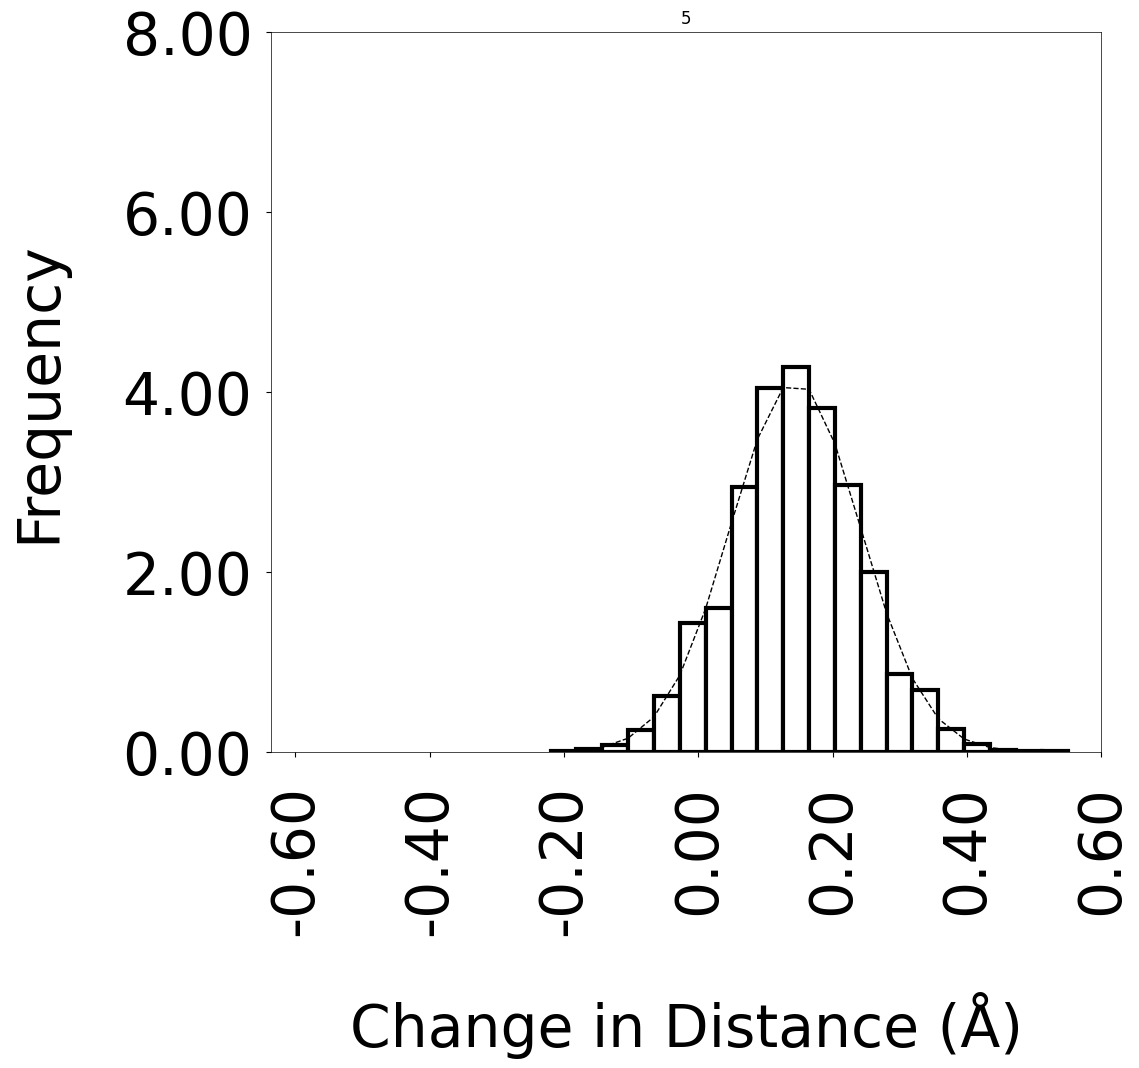

  ✓ Saved: 5_histogram.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import norm
from google.colab import files
import warnings
import logging

# GLOBAL CONFIG - ONE PLACE TO CONTROL ALL 5 PLOTS
plt.ioff()  # No figure numbers
logging.getLogger('matplotlib.font_manager').setLevel(logging.CRITICAL)
plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['pdf.fonttype'] = 42   # Embed fonts as Type 42 (TrueType) — text stays editable in Illustrator

# 🎚️ YOUR CONTROLS - CHANGE THESE NUMBERS:
plt.rcParams['figure.subplot.left'] = 0.12     # Left margin (0.10=less, 0.15=more)
plt.rcParams['figure.subplot.right'] = 0.95    # Right margin
plt.rcParams['figure.subplot.bottom'] = 0.18   # Bottom margin (0.15=less, 0.22=more)
plt.rcParams['figure.subplot.top'] = 0.90      # Top margin

# Font sizes
AXIS_LABEL_FONTSIZE = 42
TICK_LABEL_FONTSIZE = 42
TITLE_FONTSIZE = 12
LEGEND_FONTSIZE = 12
X_TICK_ROTATION = 90

# ── Overlap fix ──────────────────────────────────────────────────────────────
X_PAD = 20   # horizontal distance between x-tick labels and x-axis spine
Y_PAD = 10   # vertical distance between y-tick labels and y-axis spine
XLIM_LEFT_MARGIN = 0.03
# ─────────────────────────────────────────────────────────────────────────────

# ── Axis title spacing ───────────────────────────────────────────────────────
X_LABELPAD = 40   # gap between x-tick labels and x-axis title
Y_LABELPAD = 40   # gap between y-tick labels and y-axis title
# ─────────────────────────────────────────────────────────────────────────────

# ── PDF export (Illustrator-editable) ────────────────────────────────────────
SAVE_PDF = True   # Set False to disable PDF saving
PDF_DPI  = 300    # Resolution for any raster elements inside the PDF
# ─────────────────────────────────────────────────────────────────────────────


def _apply_overlap_fix(ax, x_min, x_max):
    """Push the first x-tick away from the y-axis on any axes object."""
    ax.tick_params(axis='x', pad=X_PAD)
    ax.tick_params(axis='y', pad=Y_PAD)
    margin = (x_max - x_min) * XLIM_LEFT_MARGIN
    ax.set_xlim(x_min - margin, ax.get_xlim()[1])


def _save_pdf(fig, plot_name, title):
    """Save figure as an Illustrator-editable PDF and trigger Colab download."""
    if not SAVE_PDF:
        return
    from matplotlib.backends.backend_pdf import PdfPages
    safe_title = "".join(c if c.isalnum() or c in (" ", "_", "-") else "_" for c in title).strip()
    safe_title = safe_title.replace(" ", "_")
    filename = f"{safe_title}_{plot_name}.pdf"
    with PdfPages(filename) as pdf:
        pdf.savefig(fig, dpi=PDF_DPI, bbox_inches="tight")
    print(f"  ✓ Saved: {filename}")
    files.download(filename)


def read_xvg(file_path):
    time = []
    distance = []
    with open(file_path, 'r') as file:
        for line in file:
            if line.startswith('#') or line.startswith('@'):
                continue
            columns = line.split()
            if len(columns) == 2:
                time.append(float(columns[0]))
                distance.append(float(columns[1]) * 10)
    return np.array(time), np.array(distance)


def calculate_changes(distance):
    return distance - distance[0]


def calculate_derivatives(time, distance):
    dt = time[1] - time[0]
    return np.gradient(distance, dt) * 10


def plot_distance(time, distance, title):
    fig = plt.figure(figsize=(15, 8))
    fig.suptitle('')
    plt.plot(time, distance, label='Distance (Å)', color='r', linestyle='-')
    plt.xlabel('Time (ps)', fontsize=AXIS_LABEL_FONTSIZE, labelpad=X_LABELPAD)
    plt.ylabel('Distance (Å)', fontsize=AXIS_LABEL_FONTSIZE, labelpad=Y_LABELPAD)
    plt.title(f'{title} - Distance Over Time', fontsize=TITLE_FONTSIZE)
    plt.legend(fontsize=LEGEND_FONTSIZE)
    plt.grid(True)
    plt.xlim(0, 20000)
    plt.ylim(np.min(distance) - 1, np.max(distance) + 1)

    major_spacing_x = 2500
    major_spacing_y = 0.5
    ax = plt.gca()
    ax.xaxis.set_major_locator(ticker.MultipleLocator(major_spacing_x))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(major_spacing_y))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
    plt.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONTSIZE)
    plt.xticks(rotation=X_TICK_ROTATION)
    for axis in ['top', 'bottom', 'left', 'right']:
        ax.spines[axis].set_linewidth(2)

    _apply_overlap_fix(ax, 0, 20000)   # ← overlap fix

    plt.show()
    _save_pdf(fig, 'distance', title)
    plt.close(fig)


def plot_distance_changes(time, change, title):
    fig = plt.figure(figsize=(14, 8))
    fig.suptitle('')
    plt.plot(time, change, label='Change in Distance (Å)', color='b', linestyle='-')
    plt.xlabel('Time (ps)', fontsize=AXIS_LABEL_FONTSIZE, labelpad=X_LABELPAD)
    plt.ylabel('Change in Distance (Å)', fontsize=AXIS_LABEL_FONTSIZE, labelpad=Y_LABELPAD)
    plt.title(f'{title} - Change in Distance Over Time', fontsize=TITLE_FONTSIZE)
    plt.legend(fontsize=LEGEND_FONTSIZE)
    plt.grid(True)
    plt.xlim(0, 20000)
    plt.ylim(np.min(change) - 0.1, np.max(change) + 0.1)

    major_spacing_x = 2500
    major_spacing_y = 0.05
    ax = plt.gca()
    ax.xaxis.set_major_locator(ticker.MultipleLocator(major_spacing_x))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(major_spacing_y))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
    plt.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONTSIZE)
    plt.xticks(rotation=X_TICK_ROTATION)
    for axis in ['top', 'bottom', 'left', 'right']:
        ax.spines[axis].set_linewidth(2)

    _apply_overlap_fix(ax, 0, 20000)   # ← overlap fix

    plt.show()
    _save_pdf(fig, 'distance_changes', title)
    plt.close(fig)


def plot_distance_derivative(time, derivative, title):
    fig = plt.figure(figsize=(14, 8))
    fig.suptitle('')
    plt.plot(time, derivative, label='dDistance/dt (Å/ps)', color='g', linestyle='-')
    plt.xlabel('Time (ps)', fontsize=AXIS_LABEL_FONTSIZE, labelpad=X_LABELPAD)
    plt.ylabel('Rate of Change (Å/ps)', fontsize=AXIS_LABEL_FONTSIZE, labelpad=Y_LABELPAD)
    plt.title(f'{title} - First Derivative of Distance Over Time', fontsize=TITLE_FONTSIZE)
    plt.grid(True)
    plt.xlim(0, 20000)
    plt.ylim(np.min(derivative) - 0.01, np.max(derivative) + 0.01)

    major_spacing_x = 2500
    major_spacing_y = 0.01
    ax = plt.gca()
    ax.xaxis.set_major_locator(ticker.MultipleLocator(major_spacing_x))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(major_spacing_y))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
    plt.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONTSIZE)
    plt.xticks(rotation=X_TICK_ROTATION)
    for axis in ['top', 'bottom', 'left', 'right']:
        ax.spines[axis].set_linewidth(1)

    _apply_overlap_fix(ax, 0, 20000)   # ← overlap fix

    plt.show()
    _save_pdf(fig, 'derivative', title)
    plt.close(fig)


def plot_histogram(data, title, xlabel, xlim=None, ylim=None):
    fig = plt.figure(figsize=(10, 10))
    fig.suptitle('')
    n, bins, patches = plt.hist(data, bins=20, color='white', alpha=1,
                                edgecolor='black', linewidth=3, density=True)
    plt.xlabel(xlabel, fontsize=AXIS_LABEL_FONTSIZE, labelpad=X_LABELPAD)
    plt.ylabel('Frequency', fontsize=AXIS_LABEL_FONTSIZE, labelpad=Y_LABELPAD)
    plt.title(title, fontsize=TITLE_FONTSIZE)

    mu, sigma = norm.fit(data)
    variance = np.var(data)
    best_fit_line = norm.pdf(bins, mu, sigma)
    plt.plot(bins, best_fit_line, 'k--', linewidth=1,
             label=f'μ = {mu:.3f}\nσ² = {variance:.3f}')

    if xlim:
        plt.xlim(xlim)
    if ylim:
        plt.ylim(ylim)

    ax = plt.gca()
    for axis in ['top', 'bottom', 'left', 'right']:
        ax.spines[axis].set_linewidth(0.5)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    plt.tick_params(axis='both', which='major', labelsize=TICK_LABEL_FONTSIZE)
    plt.xticks(rotation=X_TICK_ROTATION)

    major_spacing_x = 0.2
    major_spacing_y = 2.0
    ax.xaxis.set_major_locator(ticker.MultipleLocator(major_spacing_x))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(major_spacing_y))

    # For histograms the xlim may already be set above; derive x_min from it
    x_min = xlim[0] if xlim else np.min(data) - 1
    x_max = xlim[1] if xlim else np.max(data) + 1
    _apply_overlap_fix(ax, x_min, x_max)   # ← overlap fix

    plt.show()
    _save_pdf(fig, 'histogram', title)
    plt.close(fig)


def main():
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]
    title = input("Enter the title for the plots: ")
    time, distance = read_xvg(file_name)
    change = calculate_changes(distance)
    derivative = calculate_derivatives(time, distance)

    print("Select the plots to generate:")
    print("1. Plot raw distance over time")
    print("2. Plot change in distance over time")
    print("3. Plot first derivative of distance over time")
    print("4. Plot histogram of raw distances")
    print("5. Plot histogram of distance changes")
    choices = input("Enter your choices (comma-separated, e.g., 1,2,3): ").strip().split(',')

    if '1' in choices:
        plot_distance(time, distance, title)
    if '2' in choices:
        plot_distance_changes(time, change, title)
    if '3' in choices:
        plot_distance_derivative(time, derivative, title)
    if '4' in choices:
        plot_histogram(distance, f'{title} - Histogram of Distances', 'Distance (Å)',
                       xlim=(np.min(distance) - 1, np.max(distance) + 1), ylim=(0, 100))
    if '5' in choices:
        plot_histogram(change, f'{title}', 'Change in Distance (Å)',
                       xlim=(-0.6, 0.6), ylim=(0, 8))


if __name__ == "__main__":
    main()